In [19]:
"""
Violin plot utilities for SynOmics:  grouped violins for stability metrics with dual y-axes.
"""

from typing import Dict, List, Tuple, Optional, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Default, consistent color mapping for the two metrics (reused across plots)
VIOLIN_COLORS = {
    "Spearman": "#4c72b0",       # blue-ish (same conceptual group color)
    "Jaccard Index": "#dd8452",  # orange-ish (paired with Spearman)
}

# Default metric order used in plotting (ensures consistent color application)
METRIC_ORDER = ["Spearman", "Jaccard Index"]


def plot_metric_violins(
    scores: Dict[str, Any],
    figsize: Tuple[int, int] = (10, 6),
    palette: Optional[Dict[str, str]] = None,
    order: Optional[List[str]] = None,
    show:  bool = True,
    savepath: Optional[str] = None,
) -> Tuple[plt.Figure, plt. Axes, plt.Axes]:
    """
    Draw side-by-side violin plots for each method with dual y-axes (Spearman on left, Jaccard Index on right).

    Args:
        scores (dict): Input dictionary with keys: 
            - "Method names":  list of method names (length M).
            - "Spearman": list of length M where each element is either:
                * a list/ndarray of replicate scores for that method, or
                * a single scalar score for that method.
            - "Jaccard Index": same structure as "Spearman". 
            Example accepted structures:
            {
                "Method names": ["m1", "m2"],
                "Spearman":  [[0.9, 0.85], [0.7, 0.75]],
                "Jaccard Index": [[0.6,0.65], [0.5,0.55]]
            }
            or
            {
                "Method names": ["m1", "m2"],
                "Spearman": [0.9, 0.7],
                "Jaccard Index":  [0.6, 0.5]
            }
        figsize (tuple): Figure size. Defaults to (10, 6).
        palette (dict, optional): Mapping metric name -> color hex.  If None uses VIOLIN_COLORS.
        order (list, optional): Order of methods on the x-axis. If None, uses the order in scores["Method names"].
        show (bool): If True, calls plt.show() before returning.  Defaults to True.
        savepath (str, optional): If provided, saves the figure to this path (e.g., "out.png").

    Returns:
        matplotlib.figure.Figure: The created figure object.
        matplotlib.axes._subplots.AxesSubplot: The left axes (Spearman).
        matplotlib.axes._subplots.AxesSubplot: The right axes (Jaccard Index).

    Raises:
        ValueError: If input dictionary is missing required keys or contains inconsistent lengths.
    """
    if palette is None:
        palette = VIOLIN_COLORS

    # Validate presence of keys
    if "Method names" not in scores: 
        raise ValueError('scores must contain the key "Method names".')

    methods = list(scores["Method names"])
    if len(methods) == 0:
        raise ValueError('"Method names" must be a non-empty list.')

    # We expect both metrics to be present
    if "Spearman" not in scores or "Jaccard Index" not in scores:
        raise ValueError('Both "Spearman" and "Jaccard Index" must be present in scores.')

    # Prepare data for each metric
    def prepare_metric_data(metric_name):
        """
        Prepare metric data for plotting. 

        Args:
            metric_name (str): Name of the metric. 

        Returns:
            pd.DataFrame: DataFrame with Method and Score columns. 

        Raises:
            ValueError: If metric data is invalid.
        """
        metric_values = scores[metric_name]
        if not hasattr(metric_values, "__len__") or isinstance(metric_values, (str, bytes)):
            raise ValueError(f'Expected list-like for metric "{metric_name}".')
        
        if len(metric_values) != len(methods):
            raise ValueError(
                f'Length mismatch: "{metric_name}" has length {len(metric_values)} but "Method names" has length {len(methods)}.'
            )
        
        rows = []
        for i, method in enumerate(methods):
            val = metric_values[i]
            if hasattr(val, "__len__") and not isinstance(val, (str, bytes)):
                try:
                    for s in val:
                        rows. append({"Method": method, "Score":  float(s)})
                except TypeError:
                    rows.append({"Method": method, "Score":  float(val)})
            else:
                rows.append({"Method": method, "Score": float(val)})
        return pd.DataFrame(rows)

    df_spearman = prepare_metric_data("Spearman")
    df_jaccard = prepare_metric_data("Jaccard Index")

    # Ensure consistent method order
    if order is None: 
        order = methods

    # Create figure with dual y-axes
    sns.set(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()  # Create second y-axis

    # Compute positions for violins (manual spacing)
    n_methods = len(order)
    positions_spearman = np.arange(n_methods) - 0.2  # Shift left
    positions_jaccard = np. arange(n_methods) + 0.2   # Shift right

    # Plot Spearman violins on left axis
    parts1 = ax1.violinplot(
        [df_spearman[df_spearman["Method"] == m]["Score"]. values for m in order],
        positions=positions_spearman,
        widths=0.35,
        showmeans=False,
        showextrema=True,
        showmedians=True,
    )
    
    # Color Spearman violins
    for pc in parts1["bodies"]:
        pc.set_facecolor(palette["Spearman"])
        pc.set_edgecolor("black")
        pc.set_alpha(0.7)
        pc.set_linewidth(1.5)
    
    # Style Spearman median/extrema lines
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if partname in parts1:
            vp = parts1[partname]
            vp.set_edgecolor(palette["Spearman"])
            vp.set_linewidth(1.5)

    # Plot Jaccard violins on right axis
    parts2 = ax2.violinplot(
        [df_jaccard[df_jaccard["Method"] == m]["Score"].values for m in order],
        positions=positions_jaccard,
        widths=0.35,
        showmeans=False,
        showextrema=True,
        showmedians=True,
    )
    
    # Color Jaccard violins
    for pc in parts2["bodies"]: 
        pc.set_facecolor(palette["Jaccard Index"])
        pc.set_edgecolor("black")
        pc.set_alpha(0.7)
        pc.set_linewidth(1.5)
    
    # Style Jaccard median/extrema lines
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if partname in parts2:
            vp = parts2[partname]
            vp.set_edgecolor(palette["Jaccard Index"])
            vp.set_linewidth(1.5)

    # Configure axes
    ax1.set_ylim(0.0, 1.0)
    ax2.set_ylim(0.0, 1.0)
    
    ax1.set_ylabel("Spearman Correlation (0 - 1)", fontsize=11, fontweight="bold", color=palette["Spearman"])
    ax2.set_ylabel("Jaccard Index (0 - 1)", fontsize=11, fontweight="bold", color=palette["Jaccard Index"])
    
    ax1.tick_params(axis='y', labelcolor=palette["Spearman"])
    ax2.tick_params(axis='y', labelcolor=palette["Jaccard Index"])
    
    ax1.set_xticks(np.arange(n_methods))
    ax1.set_xticklabels(order, fontsize=10)
    ax1.set_xlabel("Method", fontsize=11, fontweight="bold")
    
    ax1.set_title("Metric Stability per Method", fontsize=13, fontweight="bold", pad=20)

    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=palette["Spearman"], edgecolor="black", label="Spearman", alpha=0.7),
        Patch(facecolor=palette["Jaccard Index"], edgecolor="black", label="Jaccard Index", alpha=0.7),
    ]
    ax1.legend(handles=legend_elements, loc="upper left", frameon=True, fontsize=10)

    # Remove gridlines from ax2 to avoid duplicate grid
    ax2.grid(False)

    plt.tight_layout()

    if savepath: 
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt. show()

    return fig, ax1, ax2


In [20]:
seeds = [0,1,2,3,42]
JaccardIndexDict = {}
SpearmanCorr = {}
for seed in seeds:
    ji_df = pd.read_csv(f"CRPR_PD/Seed_{seed}/JaccardIndex_GSEA.csv")
    spearman_df = pd.read_csv(f"CRPR_PD/Seed_{seed}/Spearman_GSEA.csv")
    JaccardIndexDict[seed] = ji_df 
    SpearmanCorr[seed] = spearman_df

In [21]:
methods = ["Avatars K5","Avatars K10","CTGAN","Gaussian Copula","Synthpop", 'TVAE']
avatarsk5_jaccards = []
avatarsk10_jaccards = []
ctgan_jaccards = []
gaussian_jaccards = []
synthpop_jaccards = []
tvae_jaccards = []

avatarsk5_spearman = []
avatarsk10_spearman = []
ctgan_spearman = []
gaussian_spearman = []
synthpop_spearman = []
tvae_spearman = []

for seed in seeds: 
    jaccards_list = JaccardIndexDict[seed]['Jaccard'].values.tolist()
    avatarsk5_jaccards.append(jaccards_list[0])
    avatarsk10_jaccards.append(jaccards_list[1])
    ctgan_jaccards.append(jaccards_list[2])
    gaussian_jaccards.append(jaccards_list[3])
    synthpop_jaccards.append(jaccards_list[4])
    tvae_jaccards.append(jaccards_list[5])

    spearmans = SpearmanCorr[seed]['Spearman_rho']
    pvalues = SpearmanCorr[seed]['p_value']

    if spearmans[0]>0:
        avatarsk5_spearman.append(spearmans[0])
    else:
        avatarsk5_spearman.append(0)
        
    if spearmans[1]>0:
        avatarsk10_spearman.append(spearmans[1])
    else:
        avatarsk10_spearman.append(0)
        
    if spearmans[2]>0:
        ctgan_spearman.append(spearmans[2])
    else:
        ctgan_spearman.append(0)
        
    if spearmans[3]>0:
        gaussian_spearman.append(spearmans[3])
    else:
        gaussian_spearman.append(0)

    if spearmans[4]>0:
        synthpop_spearman.append(spearmans[4])
    else:
        synthpop_spearman.append(0)

    if spearmans[5]>0:
        tvae_spearman.append(spearmans[5])
    else:
        tvae_spearman.append(0)
        

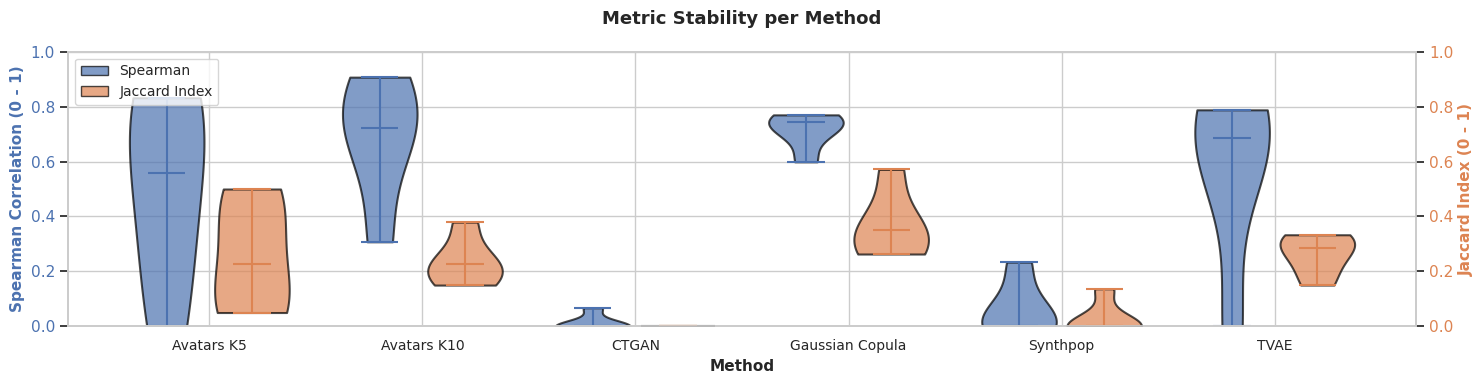

(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Metric Stability per Method'}, xlabel='Method', ylabel='Spearman Correlation (0 - 1)'>,
 <Axes: ylabel='Jaccard Index (0 - 1)'>)

In [22]:
JaccardsMap = [avatarsk5_jaccards, avatarsk10_jaccards, ctgan_jaccards, gaussian_jaccards, synthpop_jaccards,tvae_jaccards]
SpearmanMap = [avatarsk5_spearman,avatarsk10_spearman,ctgan_spearman,gaussian_spearman,synthpop_spearman,tvae_spearman]

input_scores = {
    "Method names":  methods,
    "Spearman": SpearmanMap,
    "Jaccard Index":  JaccardsMap,
}

plot_metric_violins(input_scores, figsize=(15, 4))

In [23]:
for i, tool in enumerate(methods):
    print(f"{tool}: Jaccard Index {np.mean(JaccardsMap[i])}, Spearman Correlation {np.mean(SpearmanMap[i])}")

Avatars K5: Jaccard Index 0.2516951469583048, Spearman Correlation 0.502892996203775
Avatars K10: Jaccard Index 0.23371827073476242, Spearman Correlation 0.6844892077115254
CTGAN: Jaccard Index 0.0, Spearman Correlation 0.013454981992797118
Gaussian Copula: Jaccard Index 0.3651287399739412, Spearman Correlation 0.7133481150002294
Synthpop: Jaccard Index 0.02727272727272726, Spearman Correlation 0.06507739124850229
TVAE: Jaccard Index 0.2624219640009114, Spearman Correlation 0.5654549819927971
